# Draft Figures 4 and 5
Reproduces `fig:flat` (scale-invariant spectrum vs the linear/$c_g$-only reference) and `fig:lognormal_and_peakratio` (lognormal spectra at several $f_\ast$, plus the peak-ratio curve), using only `../core` and `../kernels_data` -- no external data files.

In [1]:
import sys, os, glob
sys.path.insert(0, os.path.abspath('../core'))
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.integrate import trapezoid
import plotstyle; plotstyle.use_latex()
import kernel as K
import spectra as sp
import background_qcd as qcd

KDATA = os.path.abspath('../kernels_data')
ETA_F = 0.5
NHZ_TO_HZ = 1e-9
SIGMA = 0.4

background_qcd: solving coupled continuity-equation ODE for T(eta), a(eta)...
  norm = 0.9836281477


In [2]:
def load_tables():
    files = sorted(glob.glob(os.path.join(KDATA, 'kernel_f*.npz')),
                   key=lambda fn: float(np.load(fn)['f_nHz']))
    tabs = [np.load(fn) for fn in files]
    f_nHz = np.array([float(t['f_nHz']) for t in tabs])
    ks = np.array([float(t['k']) for t in tabs])
    return tabs, f_nHz, ks

def Ph_from_table(tab, pz, k):
    t, s, I2 = tab['t'], tab['s'], tab['I2bar']
    T, S = np.meshgrid(t, s, indexing='ij')
    W = K.weight(T, S) * pz(k * K.u_of(T, S)) * pz(k * K.v_of(T, S))
    return 4.0 * trapezoid(trapezoid(W * I2, x=s, axis=1), x=t)

tabs, f_nHz_nodes, ks_nodes = load_tables()
print(f'{len(tabs)} k-nodes loaded from {KDATA}')

60 k-nodes loaded from /Users/gabrielefranciolini/Library/CloudStorage/GoogleDrive-gabriele.franciolini@unipd.it/My Drive/Physics/Projects_Ongoing/SIGW_QCD_Kernels/Claude_Code/Code_final/kernels_data


## Figure 4 -- flat (scale-invariant) spectrum
QCD result from the tabulated kernels vs. the *linear* reference (exact-RD kernel, $\eta_c=1/k$, dilution factor $c_g(k)$ only). The RD reference here uses `kernel.I2bar_rd_exact` -- a closed form, no mode-function solve needed -- rather than a stored data file.

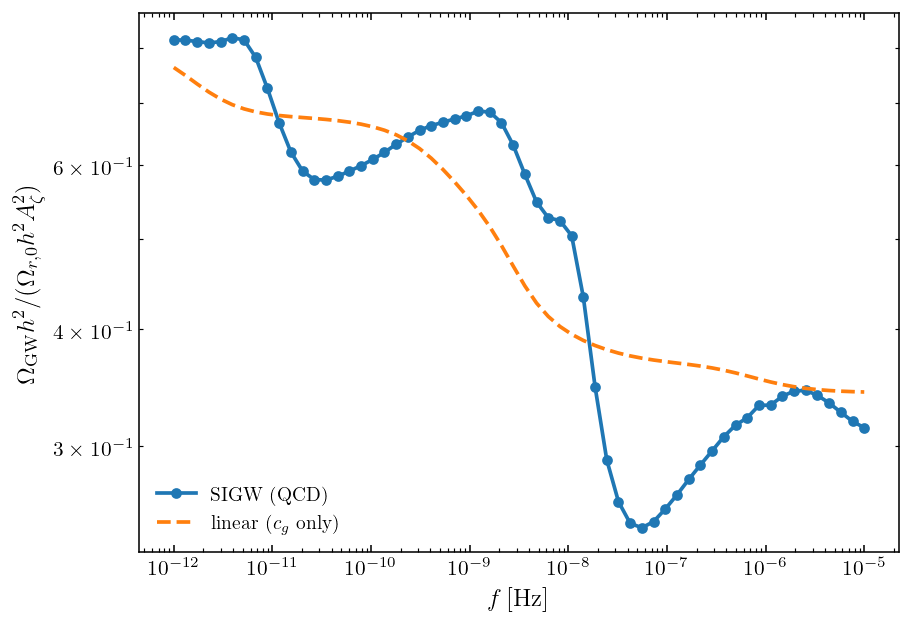

In [3]:
Ph_tab = np.array([Ph_from_table(t, sp.flat, k) for t, k in zip(tabs, ks_nodes)])
om_tab = np.array([sp.omega_gw(float(k), p, qcd, ETA_F) for k, p in zip(ks_nodes, Ph_tab)])

Ph_rd = sp.Ph(1.0, ('flat',), i2bar=K.I2bar_rd_exact, n_s=201, n_seg=300, t_max_flat=30000.0)
om_lin = np.array([sp.omega_gw(float(k), Ph_rd, qcd, ETA_F, eta_c=1.0 / float(k)) for k in ks_nodes])

fig, ax = plt.subplots(figsize=(7.0, 5.0))
ax.loglog(f_nHz_nodes * NHZ_TO_HZ, om_tab, 'o-', ms=4.5, lw=1.9, color='C0', label='SIGW (QCD)')
ax.loglog(f_nHz_nodes * NHZ_TO_HZ, om_lin, '--', lw=1.9, color='C1', label=r'linear ($c_g$ only)')
ax.set_xlabel(r'$f\,[\mathrm{Hz}]$')
ax.set_ylabel(r'$\Omega_{\rm GW}h^2/(\Omega_{r,0}h^2A_\zeta^2)$')
ax.legend(loc='lower left')
plt.show()

## Figure 5 -- lognormal spectra + peak ratio
Left: induced spectra for $\sigma=0.4$ lognormal $\mathcal{P}_\zeta$ at four $f_\ast$ (QCD, solid) against the RD, $c_g$-rescaled prediction (dashed, computed on-the-fly, no stored data). Right: ratio of peak amplitudes, QCD vs RD-$c_g$, as a function of $f_\ast$.

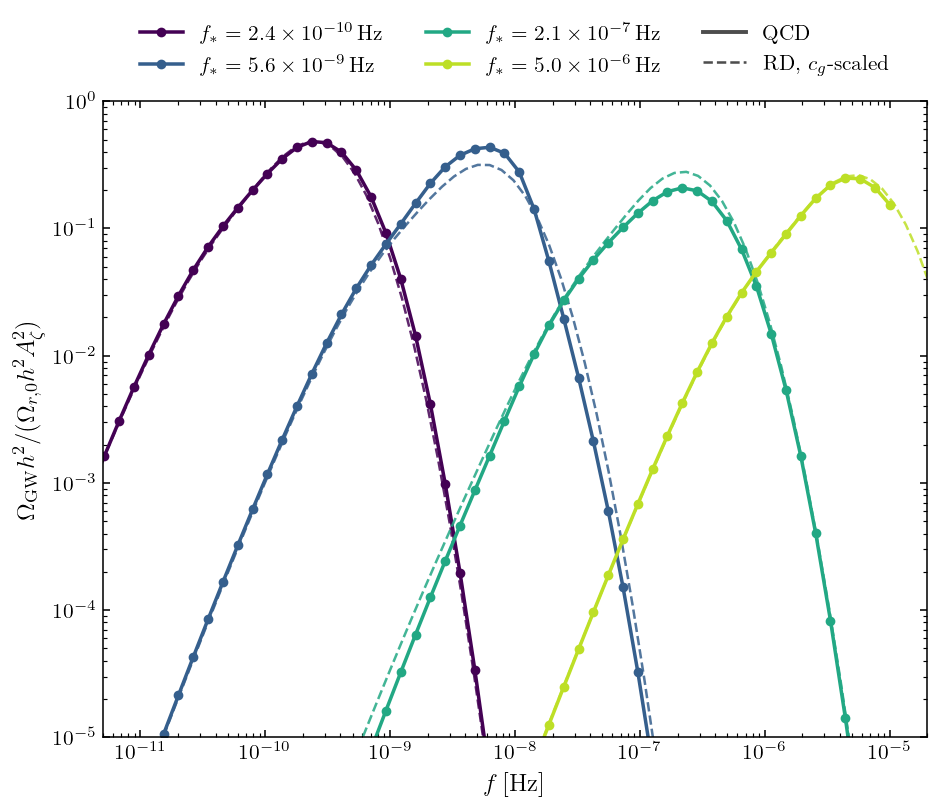

In [4]:
fstars_nHz = [0.24, 5.6, 210.0, 5000.0]
colors = cm.viridis(np.linspace(0.0, 0.9, len(fstars_nHz)))

fig, ax = plt.subplots(figsize=(7.6, 5.9))
for fstar_nHz, c in zip(fstars_nHz, colors):
    kstar = float(sp.f_Hz_to_k(np.array([fstar_nHz * 1e-9]))[0])
    spec = ('lognormal', kstar, SIGMA)
    pz = sp.make_pzeta(spec)
    Ph_qcd = np.array([Ph_from_table(t, pz, k) for t, k in zip(tabs, ks_nodes)])
    om_qcd = np.array([sp.omega_gw(float(k), p, qcd, ETA_F) for k, p in zip(ks_nodes, Ph_qcd)])

    f_rd = np.geomspace(max(fstar_nHz * 1e-3, 1e-4), fstar_nHz * 30.0, 48)
    ks_rd = sp.f_Hz_to_k(f_rd * 1e-9)
    Ph_rd = np.array([sp.Ph(float(k), spec, i2bar=K.I2bar_rd_exact, n_s=51, n_seg=100) for k in ks_rd])
    om_rd = np.array([sp.omega_gw(float(k), p, qcd, ETA_F, eta_c=1.0 / float(k)) for k, p in zip(ks_rd, Ph_rd)])

    fstar_Hz = fstar_nHz * 1e-9
    expo = int(np.floor(np.log10(fstar_Hz)))
    mant = fstar_Hz / 10.0**expo
    lab = rf'$f_\ast={mant:.1f}\times10^{{{expo}}}\,$Hz'
    ax.loglog(f_rd * NHZ_TO_HZ, om_rd, '--', lw=1.3, color=c, alpha=0.85)
    ax.loglog(f_nHz_nodes * NHZ_TO_HZ, om_qcd, 'o-', ms=4, lw=1.8, color=c, label=lab)

ax.plot([], [], '-', lw=2.0, color='0.3', label='QCD')
ax.plot([], [], '--', lw=1.3, color='0.3', label=r'RD, $c_g$-scaled')
ax.set_ylim(1e-5, 1.0); ax.set_xlim(5e-12, 2e-5)
ax.set_xlabel(r'$f\,[\mathrm{Hz}]$')
ax.set_ylabel(r'$\Omega_{\rm GW}h^2/(\Omega_{r,0}h^2A_\zeta^2)$')
ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.01), ncol=3, fontsize=11, frameon=False)
plt.show()

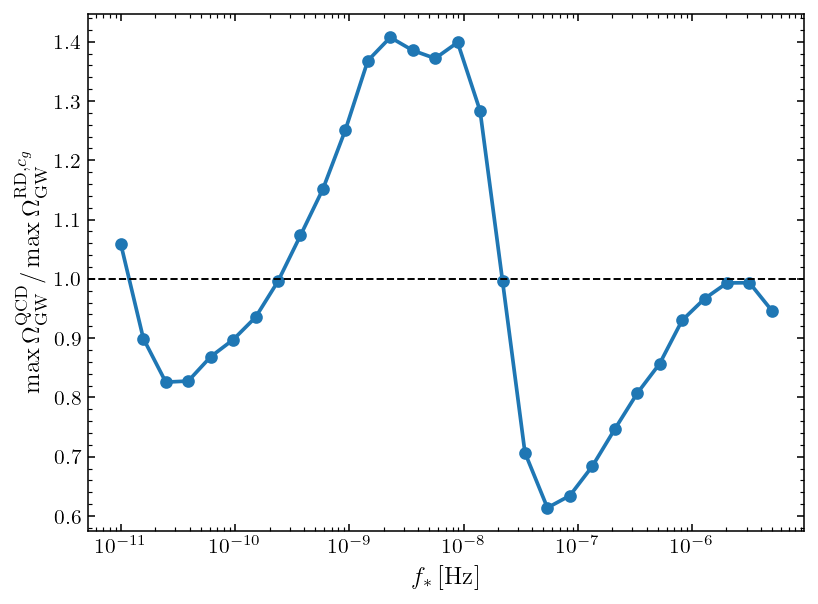

In [5]:
fstars_scan_nHz = np.geomspace(0.01, 5e3, 30)
peak_q = np.empty(len(fstars_scan_nHz))
peak_r = np.empty(len(fstars_scan_nHz))
for i, fstar_nHz in enumerate(fstars_scan_nHz):
    kstar = float(sp.f_Hz_to_k(np.array([fstar_nHz * 1e-9]))[0])
    spec = ('lognormal', kstar, SIGMA)
    pz = sp.make_pzeta(spec)
    Ph_qcd = np.array([Ph_from_table(t, pz, k) for t, k in zip(tabs, ks_nodes)])
    om_qcd = np.array([sp.omega_gw(float(k), p, qcd, ETA_F) for k, p in zip(ks_nodes, Ph_qcd)])
    f_rd = np.geomspace(max(fstar_nHz * 1e-3, 1e-4), min(fstar_nHz * 3.0, 3e4), 40)
    ks_rd = sp.f_Hz_to_k(f_rd * 1e-9)
    Ph_rd = np.array([sp.Ph(float(k), spec, i2bar=K.I2bar_rd_exact, n_s=51, n_seg=100) for k in ks_rd])
    om_rd = np.array([sp.omega_gw(float(k), p, qcd, ETA_F, eta_c=1.0 / float(k)) for k, p in zip(ks_rd, Ph_rd)])
    peak_q[i], peak_r[i] = om_qcd.max(), om_rd.max()

fig, ax = plt.subplots(figsize=(6.6, 4.8))
ax.semilogx(fstars_scan_nHz * NHZ_TO_HZ, peak_q / peak_r, 'o-', ms=5.5, lw=1.9, color='C0')
ax.axhline(1.0, color='k', lw=1.0, ls='--')
ax.set_xlabel(r'$f_\ast\,[\mathrm{Hz}]$')
ax.set_ylabel(r'$\max\Omega_{\rm GW}^{\rm QCD}/\max\Omega_{\rm GW}^{{\rm RD},c_g}$')
plt.show()